# Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Load Dataset

In [2]:
df = pd.read_csv("Twitter_Data.csv")

# View Dataset

In [3]:
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


In [5]:
df.shape

(162980, 2)

# Check Missing Values

In [6]:
df.isnull().sum()

clean_text    4
category      7
dtype: int64

# Remove Missing Values

In [7]:
df.dropna(inplace=True)

# Check Duplicate Values

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop_duplicates(inplace=True)

# Sentiment Distribution

In [10]:
df["category"].value_counts()

category
 1.0    72249
 0.0    55211
-1.0    35509
Name: count, dtype: int64

# Visualize Sentiment

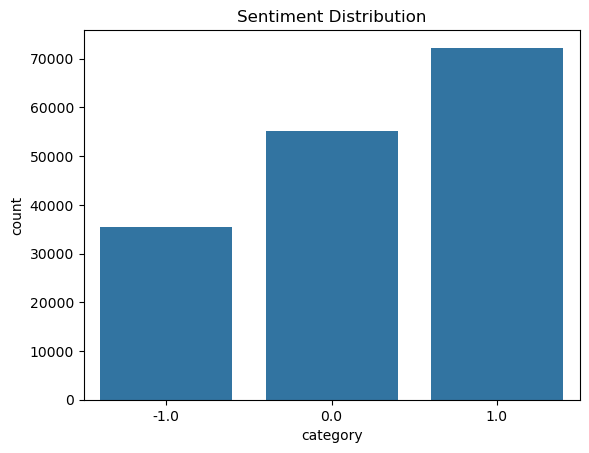

In [11]:
sns.countplot(x="category", data=df)

plt.title("Sentiment Distribution")

plt.show()

# Download NLTK Resources

In [12]:
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aditi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\aditi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# Text Cleaning

In [13]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

def preprocess(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#", "", text)

    text = re.sub(r"\d+", "", text)

    text = text.translate(str.maketrans("", "", string.punctuation))

    words = text.split()

    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

# Apply Cleaning

In [14]:
df["cleaned_text"] = df["clean_text"].apply(preprocess)

# Feature Engineering (TF-IDF)

In [15]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["cleaned_text"])

y = df["category"]

# Split Dataset

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Naive Bayes Model

In [17]:
nb = MultinomialNB()

nb.fit(X_train, y_train)

MultinomialNB()

# Prediction

In [18]:
y_pred = nb.predict(X_test)

# Accuracy

In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7164202000368166


# Classification Report

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        -1.0       0.87      0.42      0.56      7152
         0.0       0.82      0.64      0.72     11067
         1.0       0.65      0.92      0.76     14375

    accuracy                           0.72     32594
   macro avg       0.78      0.66      0.68     32594
weighted avg       0.75      0.72      0.70     32594



# Confusion Matrix

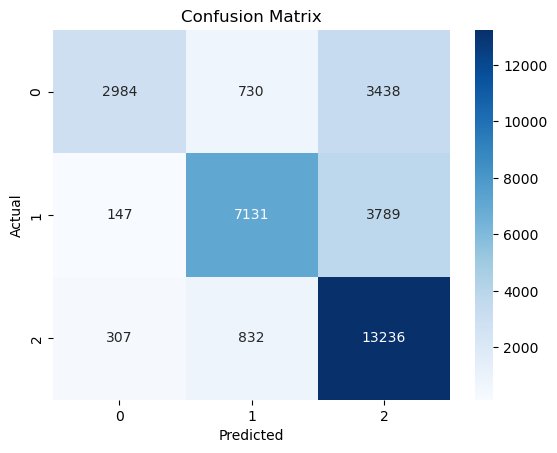

In [21]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

# Train SVM Model

In [22]:
svm = LinearSVC()

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.889887709394367


# Compare Models

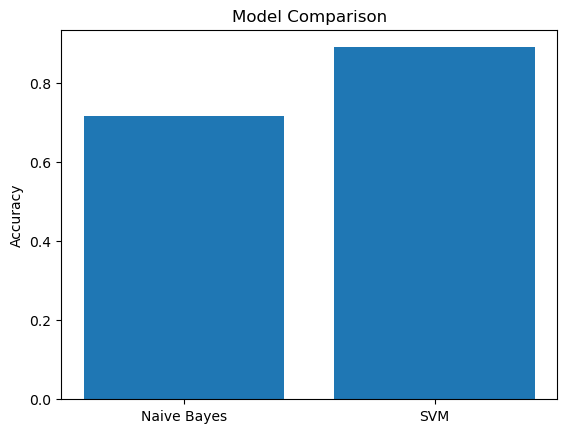

In [23]:
models = ["Naive Bayes", "SVM"]

accuracy = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, svm_pred)
]

plt.bar(models, accuracy)

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()

 # Predict Custom Text

In [24]:
text = ["This government is doing a great job"]

text = [preprocess(i) for i in text]

text = tfidf.transform(text)

prediction = svm.predict(text)

print(prediction)

[1.]
